Importing Required Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Loading the dataset

In [2]:
df = pd.read_csv('/content/ecommerce_customer_data_large.csv')

Initial Inspection

In [3]:
df.shape

(250000, 13)

In [4]:
df.head()

,Customer ID,Purchase Date,Product Category,Product Price,Quantity,Total Purchase Amount,Payment Method,Customer Age,Returns,Customer Name,Age,Gender,Churn
0,44605,2023-05-03 21:30:02,Home,177,1,2427,PayPal,31,1.0,John Rivera,31,Female,0
1,44605,2021-05-16 13:57:44,Electronics,174,3,2448,PayPal,31,1.0,John Rivera,31,Female,0
2,44605,2020-07-13 06:16:57,Books,413,1,2345,Credit Card,31,1.0,John Rivera,31,Female,0
3,44605,2023-01-17 13:14:36,Electronics,396,3,937,Cash,31,0.0,John Rivera,31,Female,0
4,44605,2021-05-01 11:29:27,Books,259,4,2598,PayPal,31,1.0,John Rivera,31,Female,0


In [5]:
df.tail()

,Customer ID,Purchase Date,Product Category,Product Price,Quantity,Total Purchase Amount,Payment Method,Customer Age,Returns,Customer Name,Age,Gender,Churn
249995,33807,2023-01-24 12:32:18,Home,436,1,3664,Cash,63,0.0,Gabriel Williams,63,Male,0
249996,20455,2021-06-04 05:45:25,Electronics,233,1,4374,Credit Card,66,1.0,Barry Foster,66,Female,0
249997,28055,2022-11-10 17:11:57,Electronics,441,5,5296,Cash,63,NaN,Lisa Johnson,63,Female,0
249998,15023,2021-06-27 14:42:12,Electronics,44,2,2517,Cash,64,1.0,Melissa Fernandez,64,Male,0
249999,4148,2020-09-07 05:12:19,Home,307,5,3634,Cash,32,0.0,Angela Norton,32,Male,0


In [6]:
df.describe()

,Customer ID,Product Price,Quantity,Total Purchase Amount,Customer Age,Returns,Age,Churn
count,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,202618.000000,250000.000000,250000.00000
mean,25017.632092,254.742724,3.004936,2725.385196,43.798276,0.500824,43.798276,0.20052
std,14412.515718,141.738104,1.414737,1442.576095,15.364915,0.500001,15.364915,0.40039
min,1.000000,10.000000,1.000000,100.000000,18.000000,0.000000,18.000000,0.00000
25%,12590.000000,132.000000,2.000000,1476.000000,30.000000,0.000000,30.000000,0.00000
50%,25011.000000,255.000000,3.000000,2725.000000,44.000000,1.000000,44.000000,0.00000
75%,37441.250000,377.000000,4.000000,3975.000000,57.000000,1.000000,57.000000,0.00000
max,50000.000000,500.000000,5.000000,5350.000000,70.000000,1.000000,70.000000,1.00000


In [7]:
df.describe(include='object')

,Purchase Date,Product Category,Payment Method,Customer Name,Gender
count,250000,250000,250000,250000,250000
unique,249728,4,3,39878,2
top,2021-11-30 18:52:48,Electronics,Credit Card,Michael Johnson,Male
freq,2,62630,83547,119,125676


In [8]:
df.columns

Index(['Customer ID', 'Purchase Date', 'Product Category', 'Product Price',
       'Quantity', 'Total Purchase Amount', 'Payment Method', 'Customer Age',
       'Returns', 'Customer Name', 'Age', 'Gender', 'Churn'],
      dtype='object')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 13 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Customer ID            250000 non-null  int64  
 1   Purchase Date          250000 non-null  object 
 2   Product Category       250000 non-null  object 
 3   Product Price          250000 non-null  int64  
 4   Quantity               250000 non-null  int64  
 5   Total Purchase Amount  250000 non-null  int64  
 6   Payment Method         250000 non-null  object 
 7   Customer Age           250000 non-null  int64  
 8   Returns                202618 non-null  float64
 9   Customer Name          250000 non-null  object 
 10  Age                    250000 non-null  int64  
 11  Gender                 250000 non-null  object 
 12  Churn                  250000 non-null  int64  
dtypes: float64(1), int64(7), object(5)
memory usage: 24.8+ MB


Checking Missing Values

In [10]:
df.isnull().sum()

,0
Customer ID,0
Purchase Date,0
Product Category,0
Product Price,0
Quantity,0
Total Purchase Amount,0
Payment Method,0
Customer Age,0
Returns,47382
Customer Name,0


Checking for duplicated rows

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df.dtypes

,0
Customer ID,int64
Purchase Date,object
Product Category,object
Product Price,int64
Quantity,int64
Total Purchase Amount,int64
Payment Method,object
Customer Age,int64
Returns,float64
Customer Name,object


In [13]:
for col in df.select_dtypes(include='object').columns:
    print(f"\n{col}")
    print(df[col].unique()[:10])


Purchase Date
['2023-05-03 21:30:02' '2021-05-16 13:57:44' '2020-07-13 06:16:57'
 '2023-01-17 13:14:36' '2021-05-01 11:29:27' '2022-08-25 06:48:33'
 '2023-07-25 05:17:24' '2023-02-05 19:31:48' '2021-12-21 03:29:05'
 '2023-02-09 00:53:14']

Product Category
['Home' 'Electronics' 'Books' 'Clothing']

Payment Method
['PayPal' 'Credit Card' 'Cash']

Customer Name
['John Rivera' 'Lauren Johnson' 'Carol Allen' 'Curtis Smith' 'Jose Green'
 'Linda Lee' 'Joshua Davis' 'Ellen Kent' 'Cheryl Espinoza'
 'Cheyenne James']

Gender
['Female' 'Male']


Data Cleaning

In [16]:
df['Returns'].isnull().sum()

np.int64(47382)

In [17]:
df['Returns'].value_counts(dropna=False)

,count
Returns,
1.0,101476
0.0,101142
NaN,47382


In [20]:
df['Purchase Date'] = pd.to_datetime(df['Purchase Date'])

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 13 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   Customer ID            250000 non-null  int64         
 1   Purchase Date          250000 non-null  datetime64[ns]
 2   Product Category       250000 non-null  object        
 3   Product Price          250000 non-null  int64         
 4   Quantity               250000 non-null  int64         
 5   Total Purchase Amount  250000 non-null  int64         
 6   Payment Method         250000 non-null  object        
 7   Customer Age           250000 non-null  int64         
 8   Returns                202618 non-null  float64       
 9   Customer Name          250000 non-null  object        
 10  Age                    250000 non-null  int64         
 11  Gender                 250000 non-null  object        
 12  Churn                  250000 non-null  int6

In [24]:
(df['Age'] == df['Customer Age']).all()

np.True_

In [25]:
df.drop(columns=['Customer Age'], inplace=True)

In [26]:
df[df['Returns'].isnull()].head()

,Customer ID,Purchase Date,Product Category,Product Price,Quantity,Total Purchase Amount,Payment Method,Returns,Customer Name,Age,Gender,Churn
6,13738,2023-07-25 05:17:24,Electronics,205,1,2773,Credit Card,NaN,Lauren Johnson,27,Female,0
8,13738,2021-12-21 03:29:05,Home,12,2,2175,Cash,NaN,Lauren Johnson,27,Female,0
10,33969,2023-02-28 19:58:23,Clothing,410,3,5018,Credit Card,NaN,Carol Allen,27,Male,0
21,42650,2022-01-26 12:50:30,Electronics,105,2,3721,Credit Card,NaN,Curtis Smith,20,Female,0
26,42650,2020-05-24 06:45:48,Electronics,307,3,973,PayPal,NaN,Curtis Smith,20,Female,0


In [27]:
df['Returns'] = df['Returns'].fillna(0)
df['Returns'] = df['Returns'].astype(int)

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 12 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   Customer ID            250000 non-null  int64         
 1   Purchase Date          250000 non-null  datetime64[ns]
 2   Product Category       250000 non-null  object        
 3   Product Price          250000 non-null  int64         
 4   Quantity               250000 non-null  int64         
 5   Total Purchase Amount  250000 non-null  int64         
 6   Payment Method         250000 non-null  object        
 7   Returns                250000 non-null  int64         
 8   Customer Name          250000 non-null  object        
 9   Age                    250000 non-null  int64         
 10  Gender                 250000 non-null  object        
 11  Churn                  250000 non-null  int64         
dtypes: datetime64[ns](1), int64(7), object(4)
me

Feature Engineering

In [29]:
df['Year'] = df['Purchase Date'].dt.year

df['Month'] = df['Purchase Date'].dt.month

df['Month Name'] = df['Purchase Date'].dt.month_name()

df['Quarter'] = df['Purchase Date'].dt.quarter

df['Day'] = df['Purchase Date'].dt.day_name()

df['Weekend'] = df['Purchase Date'].dt.dayofweek >= 5

In [31]:
df['Weekend'] = df['Weekend'].map({
    True: 'Weekend',
    False: 'Weekday'
})

Exploratory data analysis

In [32]:
plt.rcParams['figure.figsize'] = (10,5)

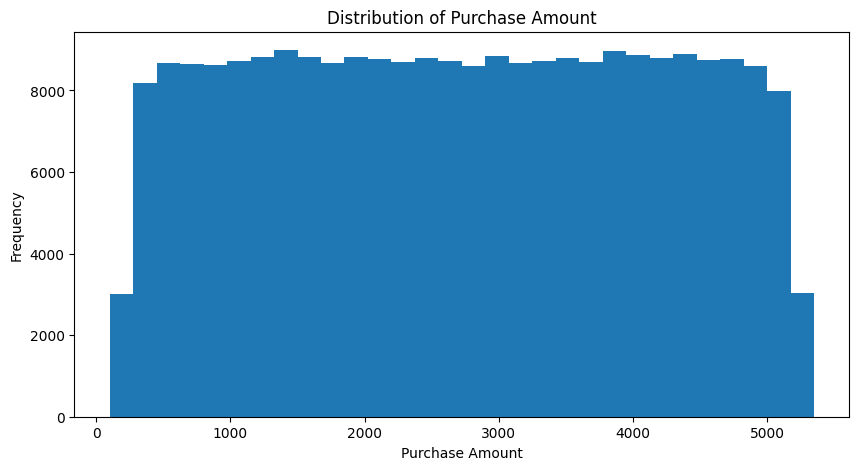

In [33]:
plt.figure(figsize=(10,5))
plt.hist(df['Total Purchase Amount'], bins=30)
plt.title("Distribution of Purchase Amount")
plt.xlabel("Purchase Amount")
plt.ylabel("Frequency")
plt.show()

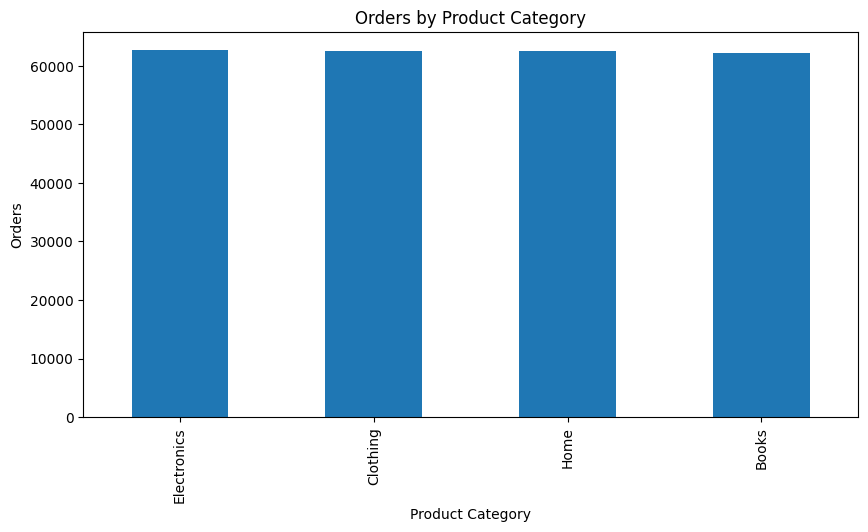

In [34]:
category_orders = df['Product Category'].value_counts()
category_orders.plot(kind='bar')

plt.title("Orders by Product Category")
plt.ylabel("Orders")
plt.show()

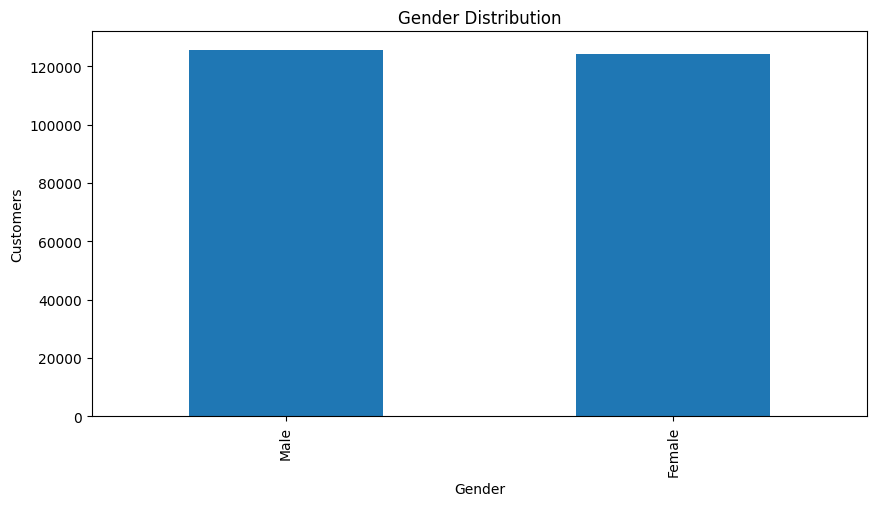

In [35]:
df['Gender'].value_counts().plot(kind='bar')

plt.title("Gender Distribution")
plt.ylabel("Customers")
plt.show()

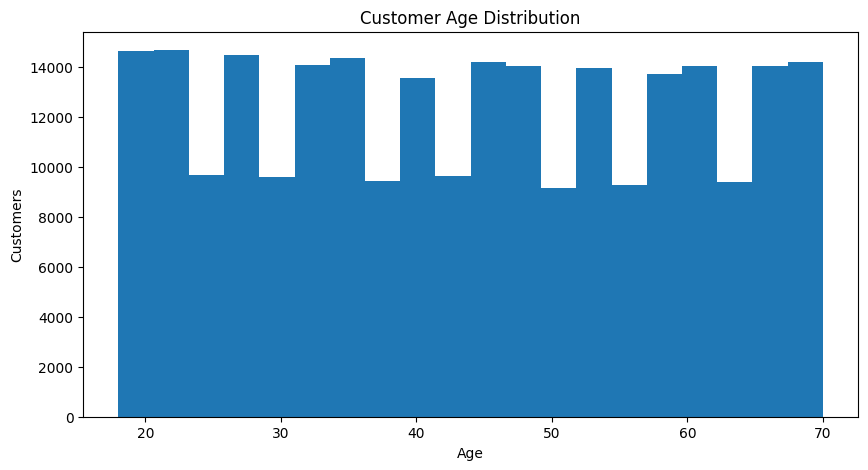

In [36]:
plt.hist(df['Age'], bins=20)
plt.title("Customer Age Distribution")
plt.xlabel("Age")
plt.ylabel("Customers")
plt.show()

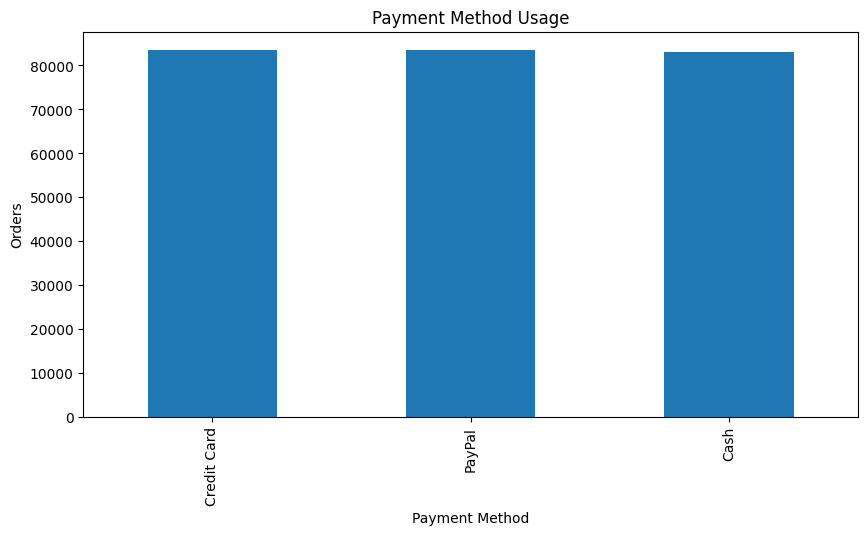

In [37]:
payment = df['Payment Method'].value_counts()

payment.plot(kind='bar')

plt.title("Payment Method Usage")
plt.ylabel("Orders")
plt.show()

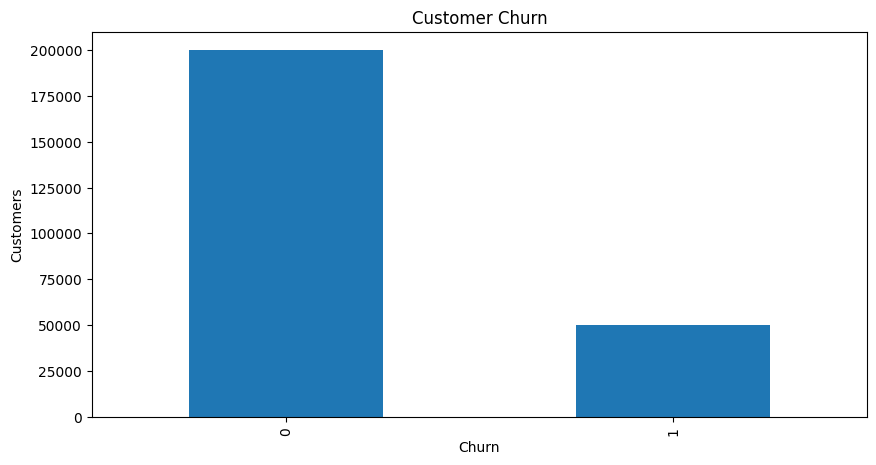

In [38]:
churn = df['Churn'].value_counts()

churn.plot(kind='bar')

plt.title("Customer Churn")
plt.ylabel("Customers")
plt.show()

In [39]:
df.to_csv('cleaned_data.csv')

In [41]:
df.shape

(250000, 18)